# Vergleich: Kameradistanz


In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway


In [15]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '05_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_camera_distance.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

if 'influencer_type' not in df.columns and 'source' in df.columns:
    df['influencer_type'] = df['source']

if 'video_engagement_rate' not in df.columns:
    like_col = 'video_like_count' if 'video_like_count' in df.columns else ('likes' if 'likes' in df.columns else None)
    comment_col = 'video_comment_count' if 'video_comment_count' in df.columns else ('comments' if 'comments' in df.columns else None)
    share_col = 'video_share_count' if 'video_share_count' in df.columns else ('shares' if 'shares' in df.columns else None)
    view_col = 'video_view_count' if 'video_view_count' in df.columns else ('plays' if 'plays' in df.columns else None)
    if all(c is not None for c in [like_col, comment_col, share_col, view_col]):
        df['video_engagement_rate'] = (
            df[like_col].fillna(0) + df[comment_col].fillna(0) + df[share_col].fillna(0)
        ) / df[view_col].replace(0, pd.NA)

label_col = 'camera_distance_label' 
conf_col = 'camera_distance_confidence'
unique_col = 'camera_distance_unique_labels' 

if label_col is None:
    raise ValueError('No camera distance label column found.')

CAMERA_DISTANCE_LABELS = {
    'ambiguous': 'Ambiguous',
    'closeUp': 'Close-up',
    'detail': 'Detail',
    'extremeLongShot': 'Extreme Long Shot',
    'fullShot': 'Full Shot',
    'longShot': 'Long Shot',
    'mediumCloseUp': 'Medium Close-up',
    'mediumShot': 'Medium Shot',
}
df['camera_distance_label_readable'] = (
    df[label_col]
    .fillna('Unbestimmt')
    .astype(str)
    .map(lambda label: CAMERA_DISTANCE_LABELS.get(label, label.replace('_', ' ').strip().title()))
)

print('Rows:', len(df))
print('Label col:', label_col)
print('Confidence col:', conf_col)
print('Unique-label col:', unique_col)

base_cols = ['influencer_type']
if conf_col:
    base_cols.append(conf_col)
if unique_col:
    base_cols.append(unique_col)
if len(base_cols) > 1:
    print(df[base_cols].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/05_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_camera_distance.csvRows: 500Label col: camera_distance_labelConfidence col: camera_distance_confidenceUnique-label col: camera_distance_unique_labels                camera_distance_confidence                      \                                     count      mean       std   influencer_type                                                  ai                                     250  0.770239  0.105253   real                                   250  0.758118  0.105587                   camera_distance_unique_labels                                                          count   mean      std  influencer_type                                                ai                                        250  1.944  1.24703  real                                      250  2.428  1.35505  

In [4]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [5]:
# Beispiele mit hoher und niedriger Kameradistanz-Konfidenz anzeigen
if conf_col is not None:
    _df = df.dropna(subset=[conf_col]).copy()
else:
    _df = pd.DataFrame([])

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        conf = row.get(conf_col, np.nan) if conf_col else np.nan
        label = row.get('camera_distance_label_readable', '')
        unique_n = row.get(unique_col, np.nan) if unique_col else np.nan
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(
            f'{title} | id={vid} | type={inf} | label={label} | conf={conf:.2f} | unique={unique_n}'
        )

    plt.tight_layout()
    plt.show()

if conf_col is not None and not _df.empty:
    high_conf = pick_examples(_df.sort_values(conf_col, ascending=False), n=4)
    low_conf = pick_examples(_df.sort_values(conf_col, ascending=True), n=4)
    show_examples(high_conf, 'Hohe Camera-Distance-Confidence')
    show_examples(low_conf, 'Niedrige Camera-Distance-Confidence')
else:
    print('No confidence column available for examples.')


No frames found for Hohe Camera-Distance-Confidence
No frames found for Niedrige Camera-Distance-Confidence


In [16]:
summary_cols = []
if conf_col:
    summary_cols.append(conf_col)
if unique_col:
    summary_cols.append(unique_col)

if summary_cols:
    summary = df.groupby('influencer_type')[summary_cols].describe().round(2)
    display(summary)

top_labels = (
    df.groupby(['camera_distance_label_readable', 'influencer_type'])
      .size()
      .unstack(fill_value=0)
      .sort_values(by=list(df['influencer_type'].dropna().unique())[:1], ascending=False)
      .head(15)
)
display(top_labels)


camera_distance_confidence                                \
                                     count  mean   std   min   25%   50%   
influencer_type                                                            
ai                                   250.0  0.77  0.11  0.54  0.69  0.78   
real                                 250.0  0.76  0.11  0.51  0.68  0.77   

                            camera_distance_unique_labels                   \
                  75%   max                         count  mean   std  min   
influencer_type                                                              
ai               0.85  0.99                         250.0  1.94  1.25  1.0   
real             0.83  0.99                         250.0  2.43  1.36  1.0   

                                     
                 25%  50%  75%  max  
influencer_type                      
ai               1.0  2.0  2.0  7.0  
real             1.0  2.0  3.0  7.0

influencer_type,ai,real
camera_distance_label_readable,,
Medium Close-up,102,85
Medium Shot,95,94
Full Shot,23,20
Close-up,19,23
Long Shot,7,14
Detail,2,1
Ambiguous,1,2
Extreme Long Shot,1,11


/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_88773/225144071.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_88773/225144071.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_88773/225144071.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


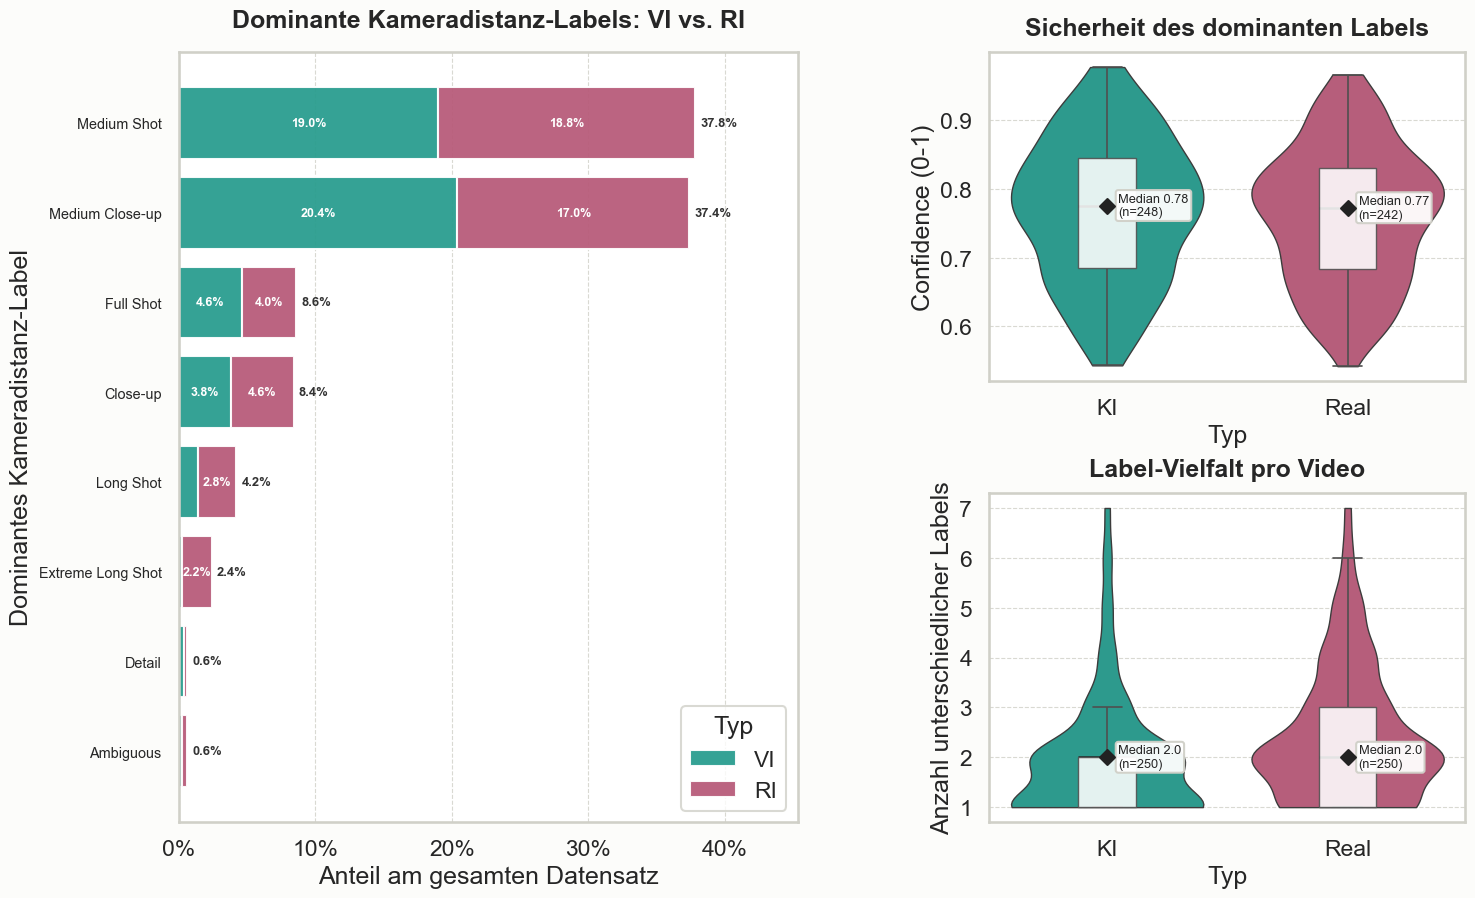

In [18]:
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': '#fcfcfa',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

ORDER = ['KI', 'Real']
PALETTE_COLOR = {'KI': '#2A9D8F', 'Real': '#B85C7A'}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

label_counts = (
    df_plot.groupby(['camera_distance_label_readable', 'typ']).size().unstack(fill_value=0).reindex(columns=ORDER, fill_value=0)
)
label_counts['gesamt'] = label_counts.sum(axis=1)
total_label_count = int(label_counts[ORDER].to_numpy().sum())
if total_label_count == 0:
    raise ValueError('Keine gültigen Kameradistanz-Labels für VI und RI gefunden.')
label_counts = label_counts.sort_values('gesamt', ascending=False).head(12).sort_values('gesamt', ascending=True)
# Jeder Balken zeigt den Anteil am gesamten Datensatz; alle Balken zusammen ergeben 100 %.
label_shares = label_counts[ORDER].div(total_label_count)
label_shares['gesamt'] = label_counts['gesamt'].div(total_label_count)
labels = label_shares.index.tolist()

fig = plt.figure(figsize=(16.6, max(10.0, 0.45 * len(labels) + 4.2)))
gs = fig.add_gridspec(2, 2, width_ratios=[1.30, 1.0], height_ratios=[1, 1], wspace=0.35, hspace=0.34)
ax_bar = plt.subplot(gs[:, 0])
ax_conf = plt.subplot(gs[0, 1])
ax_unique = plt.subplot(gs[1, 1])

# 1) Gesamthäufigkeit je Label, aufgeteilt nach KI und Real
y_pos = np.arange(len(labels))
bars_ki = ax_bar.barh(y_pos, label_shares['KI'], color=PALETTE_COLOR['KI'], alpha=0.95, label='VI')
bars_real = ax_bar.barh(y_pos, label_shares['Real'], left=label_shares['KI'], color=PALETTE_COLOR['Real'], alpha=0.95, label='RI')

ax_bar.set_title('Dominante Kameradistanz-Labels: VI vs. RI', pad=18, weight='semibold')
ax_bar.set_xlabel('Anteil am gesamten Datensatz')
ax_bar.set_ylabel('Dominantes Kameradistanz-Label')
ax_bar.set_yticks(y_pos)
ax_bar.set_yticklabels(labels, fontsize=10.4)
ax_bar.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax_bar.grid(axis='y', visible=False)
ax_bar.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='lower right')
max_total_share = float(label_shares[ORDER].sum(axis=1).max())
ax_bar.set_xlim(0, max_total_share * 1.20)

for i, (_, row) in enumerate(label_shares.iterrows()):
    ki_share = row['KI']
    real_share = row['Real']
    total_share = row['gesamt']

    if ki_share >= 0.015:
        ax_bar.text(ki_share / 2, i, f'{ki_share:.1%}', ha='center', va='center', fontsize=9.0, color='white', weight='semibold')
    if real_share >= 0.015:
        ax_bar.text(ki_share + real_share / 2, i, f'{real_share:.1%}', ha='center', va='center', fontsize=9.0, color='white', weight='semibold')

    # Rechts steht der Gesamtanteil des Labels an allen 500 Videos.
    ax_bar.text(total_share + 0.004, i, f'{total_share:.1%}', ha='left', va='center', fontsize=9.4, color='#333333', weight='semibold')

# 2) Konfidenzverteilung mit Medianwerten
if conf_col and conf_col in df_plot.columns:
    conf_df = df_plot.dropna(subset=[conf_col]).copy()
    if not conf_df.empty:
        q1, q99 = conf_df[conf_col].quantile([0.01, 0.99])
        conf_df = conf_df[(conf_df[conf_col] >= q1) & (conf_df[conf_col] <= q99)]

        conf_summary = (
            conf_df.groupby('typ')[conf_col]
            .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), n='size')
            .reindex(ORDER)
        )

        sns.violinplot(
            data=conf_df,
            x='typ',
            y=conf_col,
            order=ORDER,
            palette=PALETTE_COLOR,
            inner=None,
            cut=0,
            linewidth=1.0,
            saturation=0.95,
            ax=ax_conf,
        )
        sns.boxplot(
            data=conf_df,
            x='typ',
            y=conf_col,
            order=ORDER,
            width=0.24,
            fliersize=0,
            boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
            whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            medianprops={'color': '#222222', 'linewidth': 1.8},
            ax=ax_conf,
        )

        for i, grp in enumerate(ORDER):
            med = conf_summary.loc[grp, 'median']
            n = int(conf_summary.loc[grp, 'n']) if pd.notna(conf_summary.loc[grp, 'n']) else 0
            if pd.notna(med):
                ax_conf.scatter(i, med, s=58, marker='D', color='#222222', zorder=4)
                ax_conf.annotate(
                    f'Median {med:.2f}\n(n={n})',
                    (i, med),
                    xytext=(8, 0),
                    textcoords='offset points',
                    va='center',
                    fontsize=9.2,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
                )

    ax_conf.set_title('Sicherheit des dominanten Labels', pad=12, weight='semibold')
    ax_conf.set_xlabel('Typ')
    ax_conf.set_ylabel('Confidence (0-1)')
    ax_conf.grid(axis='x', visible=False)
else:
    ax_conf.text(0.5, 0.5, 'Keine Confidence-Spalte vorhanden', ha='center', va='center')
    ax_conf.axis('off')

# 3) Label-Vielfalt mit Medianwerten
if unique_col and unique_col in df_plot.columns:
    unique_df = df_plot.dropna(subset=[unique_col]).copy()
    if not unique_df.empty:
        unique_summary = (
            unique_df.groupby('typ')[unique_col]
            .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), n='size')
            .reindex(ORDER)
        )

        sns.violinplot(
            data=unique_df,
            x='typ',
            y=unique_col,
            order=ORDER,
            palette=PALETTE_COLOR,
            inner=None,
            cut=0,
            linewidth=1.0,
            saturation=0.95,
            ax=ax_unique,
        )
        sns.boxplot(
            data=unique_df,
            x='typ',
            y=unique_col,
            order=ORDER,
            width=0.24,
            fliersize=0,
            boxprops={'facecolor': 'white', 'alpha': 0.88, 'edgecolor': '#4f4f4f', 'zorder': 3},
            whiskerprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            capprops={'linewidth': 1.2, 'color': '#4f4f4f'},
            medianprops={'color': '#222222', 'linewidth': 1.8},
            ax=ax_unique,
        )

        for i, grp in enumerate(ORDER):
            med = unique_summary.loc[grp, 'median']
            n = int(unique_summary.loc[grp, 'n']) if pd.notna(unique_summary.loc[grp, 'n']) else 0
            if pd.notna(med):
                ax_unique.scatter(i, med, s=58, marker='D', color='#222222', zorder=4)
                ax_unique.annotate(
                    f'Median {med:.1f}\n(n={n})',
                    (i, med),
                    xytext=(8, 0),
                    textcoords='offset points',
                    va='center',
                    fontsize=9.2,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
                )

    ax_unique.set_title('Label-Vielfalt pro Video', pad=12, weight='semibold')
    ax_unique.set_xlabel('Typ')
    ax_unique.set_ylabel('Anzahl unterschiedlicher Labels')
    ax_unique.grid(axis='x', visible=False)
else:
    ax_unique.text(0.5, 0.5, 'Keine Unique-Label-Spalte vorhanden', ha='center', va='center')
    ax_unique.axis('off')

plt.tight_layout()
plt.show()


In [28]:
results = []
chi2_results = []

# Mann-Whitney-U-Test für Konfidenz
if conf_col and conf_col in df.columns:
    ai_vals = df.loc[df['influencer_type'] == 'ai', conf_col].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', conf_col].dropna()
    if len(ai_vals) > 0 and len(real_vals) > 0:
        u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
        results.append({
            'metric': conf_col,
            'test': 'Mann-Whitney-U',
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            'median_ai': ai_vals.median(),
            'median_real': real_vals.median(),
            'u_stat': u_stat,
            'u_p': u_p,
        })

# Mann-Whitney-U-Test für Labelvielfalt
if unique_col and unique_col in df.columns:
    ai_vals = df.loc[df['influencer_type'] == 'ai', unique_col].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', unique_col].dropna()
    if len(ai_vals) > 0 and len(real_vals) > 0:
        u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
        results.append({
            'metric': unique_col,
            'test': 'Mann-Whitney-U',
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            'median_ai': ai_vals.median(),
            'median_real': real_vals.median(),
            'u_stat': u_stat,
            'u_p': u_p,
        })

# Chi²-Test für Labelverteilung
tmp = df[['camera_distance_label_readable', 'influencer_type']].dropna().copy()
if not tmp.empty:
    contingency = pd.crosstab(tmp['camera_distance_label_readable'], tmp['influencer_type'])
    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
        chi2, p_val, dof, _ = chi2_contingency(contingency)
        chi2_results.append({
            'metric': 'camera_distance_label_readable',
            'test': 'Chi2',
            'chi2': chi2,
            'dof': dof,
            'p_value': p_val,
            'n': len(tmp),
        })

results_df = pd.DataFrame(results).round(4)
chi2_df = pd.DataFrame(chi2_results).round(4)

display(results_df)
display(chi2_df)


,metric,test,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,camera_distance_confidence,Mann-Whitney-U,250,250,0.7702,0.7581,0.7768,0.7708,33180.0,0.2323
1,camera_distance_unique_labels,Mann-Whitney-U,250,250,1.9440,2.4280,2.0000,2.0000,23806.5,0.0000


,metric,test,chi2,dof,p_value,n
0,camera_distance_label_readable,Chi2,13.4743,7,0.0614,500


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


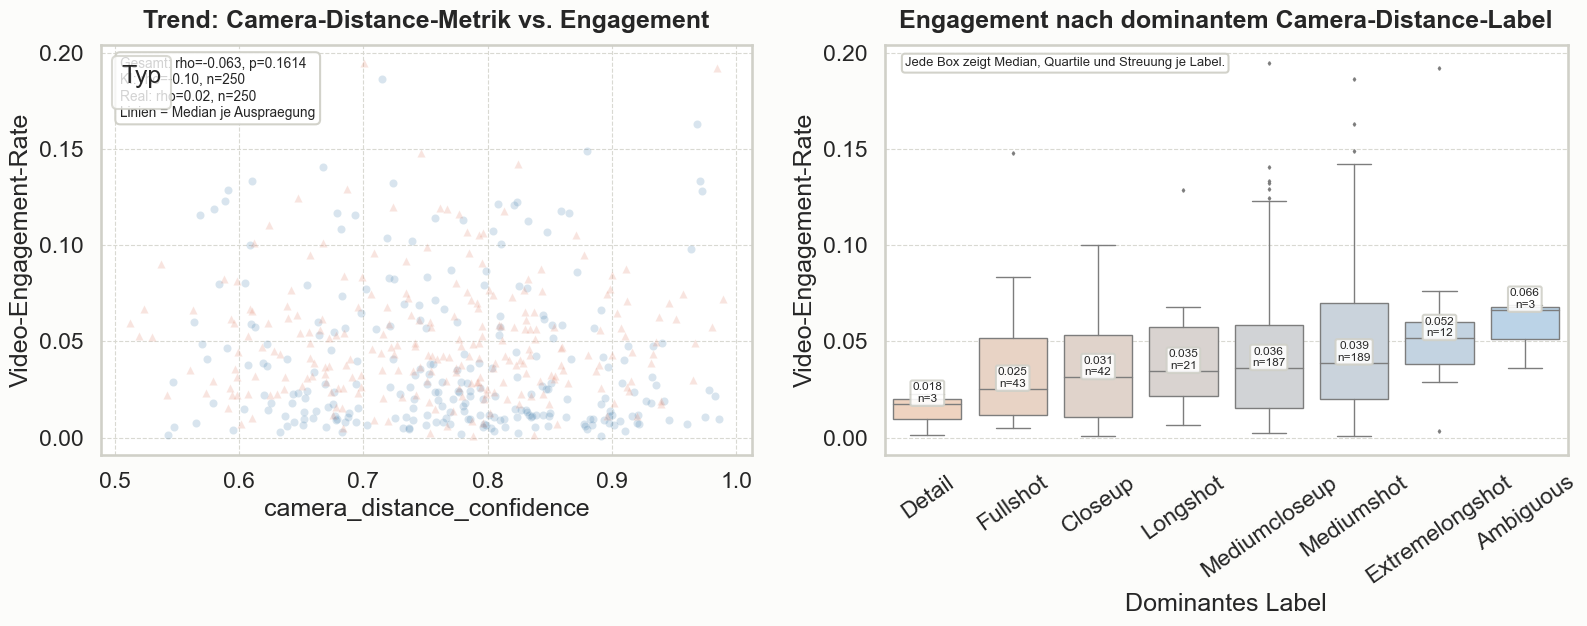

,Metrik,method,Spearman_rho,p_Wert
0,camera_distance_confidence,Spearman,-0.0627,0.1614


,Metrik,analysis,stat,p_Wert,n,R2,k_dummies
0,camera_distance_label_readable,ANOVA,1.9558,0.0593,500,NaN,NaN
1,camera_distance_label_readable,Dummy-Regression,NaN,NaN,500,0.0271,7.0


In [26]:
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': '#fcfcfa',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])
PALETTE_COLOR = {'KI': '#3F7CAC', 'Real': '#E07A5F'}
MARKER = {'KI': 'o', 'Real': '^'}

corr_results = []
anova_reg_results = []

if 'video_engagement_rate' in df_plot.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16.4, 6.6), gridspec_kw={'width_ratios': [1.05, 1.10]})
    ax_left, ax_right = axes

    metric_for_trend = conf_col if conf_col and conf_col in df_plot.columns else unique_col
    if metric_for_trend and metric_for_trend in df_plot.columns:
        plot_df = df_plot[[metric_for_trend, 'video_engagement_rate', 'typ']].dropna().copy()
        if not plot_df.empty:
            rho, pval = spearmanr(plot_df[metric_for_trend], plot_df['video_engagement_rate'], nan_policy='omit')
            corr_results.append({'Metrik': metric_for_trend, 'method': 'Spearman', 'Spearman_rho': rho, 'p_Wert': pval})

            stat_lines = []
            for grp in ['KI', 'Real']:
                sub = plot_df[plot_df['typ'] == grp].copy()
                if sub.empty:
                    continue

                sns.scatterplot(
                    data=sub,
                    x=metric_for_trend,
                    y='video_engagement_rate',
                    color=PALETTE_COLOR[grp],
                    marker=MARKER[grp],
                    edgecolor='white',
                    linewidth=0.35,
                    s=34,
                    alpha=0.20,
                    ax=ax_left,
                    legend=False,
                )

                grouped = (
                    sub.groupby(metric_for_trend)['video_engagement_rate']
                    .agg(median='median', q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75), n='size')
                    .reset_index()
                )
                grouped = grouped[grouped['n'] >= 3]
                if not grouped.empty:
                    ax_left.plot(grouped[metric_for_trend], grouped['median'], color=PALETTE_COLOR[grp], linewidth=2.5, label=grp)
                    ax_left.scatter(grouped[metric_for_trend], grouped['median'], color=PALETTE_COLOR[grp], s=52, edgecolor='white', linewidth=0.85, zorder=4)

                rho_g, p_g = spearmanr(sub[metric_for_trend], sub['video_engagement_rate'], nan_policy='omit')
                stat_lines.append(f'{grp}: rho={rho_g:.2f}, n={len(sub)}')

            ax_left.set_title('Trend: Camera-Distance-Metrik vs. Engagement', pad=12, weight='semibold')
            ax_left.set_xlabel(metric_for_trend)
            ax_left.set_ylabel('Video-Engagement-Rate')
            ax_left.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
            ax_left.text(
                0.03,
                0.97,
                f'Gesamt: rho={rho:.3f}, p={pval:.4g}\n' + '\n'.join(stat_lines) + '\nLinien = Median je Auspraegung',
                transform=ax_left.transAxes,
                ha='left',
                va='top',
                fontsize=9.8,
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
            )

    analysis_df = df_plot[['camera_distance_label_readable', 'video_engagement_rate']].dropna().copy()
    groups = [g['video_engagement_rate'].values for _, g in analysis_df.groupby('camera_distance_label_readable') if len(g) > 1]
    if len(groups) >= 2:
        f_stat, p_val = f_oneway(*groups)
        anova_reg_results.append({'Metrik': 'camera_distance_label_readable', 'analysis': 'ANOVA', 'stat': f_stat, 'p_Wert': p_val, 'n': len(analysis_df)})

    X = pd.get_dummies(analysis_df['camera_distance_label_readable'], drop_first=True, dtype=float)
    if X.shape[1] > 0:
        X_mat = np.column_stack([np.ones(len(X)), X.values])
        y = analysis_df['video_engagement_rate'].values.astype(float)
        beta, *_ = np.linalg.lstsq(X_mat, y, rcond=None)
        y_hat = X_mat @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)
        anova_reg_results.append({'Metrik': 'camera_distance_label_readable', 'analysis': 'Dummy-Regression', 'R2': r2, 'n': len(analysis_df), 'k_dummies': X.shape[1]})

    top_labels = analysis_df['camera_distance_label_readable'].value_counts().head(10).index.tolist()
    plot_label_df = analysis_df[analysis_df['camera_distance_label_readable'].isin(top_labels)].copy()
    order = plot_label_df.groupby('camera_distance_label_readable')['video_engagement_rate'].median().sort_values().index.tolist()

    sns.boxplot(
        data=plot_label_df,
        x='camera_distance_label_readable',
        y='video_engagement_rate',
        order=order,
        palette=sns.color_palette('blend:#f7d1b8,#b4d4ee', n_colors=max(3, len(order))),
        fliersize=1.8,
        linewidth=1.0,
        ax=ax_right,
    )

    med_by_label = plot_label_df.groupby('camera_distance_label_readable')['video_engagement_rate'].median()
    n_by_label = plot_label_df.groupby('camera_distance_label_readable').size()
    for i, lbl in enumerate(order):
        med = med_by_label.get(lbl, np.nan)
        n = int(n_by_label.get(lbl, 0))
        if pd.notna(med):
            ax_right.text(
                i,
                med,
                f'{med:.3f}\nn={n}',
                ha='center',
                va='bottom',
                fontsize=8.6,
                bbox=dict(boxstyle='round,pad=0.16', facecolor='white', edgecolor='#d0d0c8', alpha=0.9),
            )

    ax_right.set_title('Engagement nach dominantem Camera-Distance-Label', pad=12, weight='semibold')
    ax_right.set_xlabel('Dominantes Label')
    ax_right.set_ylabel('Video-Engagement-Rate')
    ax_right.tick_params(axis='x', rotation=35)
    ax_right.text(
        0.03,
        0.97,
        'Jede Box zeigt Median, Quartile und Streuung je Label.',
        transform=ax_right.transAxes,
        ha='left',
        va='top',
        fontsize=9.4,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )

    plt.tight_layout()
    plt.show()

corr_df = pd.DataFrame(corr_results).round(4)
anova_reg_df = pd.DataFrame(anova_reg_results).round(4)

display(corr_df)
display(anova_reg_df)


In [27]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

def fmt_p(p):
    if pd.isna(p):
        return 'NA'
    if p == 0:
        return '< 1e-308'
    if p < 1e-4:
        return f'{p:.2e}'
    return f'{p:.4f}'

results_summary = globals().get('results_df', pd.DataFrame())
chi2_summary = globals().get('chi2_df', pd.DataFrame())
corr_summary = globals().get('corr_df', pd.DataFrame())
anova_summary = globals().get('anova_reg_df', pd.DataFrame())

if not results_summary.empty:
    for _, row in results_summary.iterrows():
        mean_diff = row['mean_ai'] - row['mean_real']
        direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
        print(f"- {row['metric']} (Mann-Whitney): {sig_label(row['u_p'])} (p={fmt_p(row['u_p'])}). Interpretation: {direction}.")

if not chi2_summary.empty:
    row = chi2_summary.iloc[0]
    distribution_result = (
        'Die Label-Verteilungen unterscheiden sich zwischen KI und Real.'
        if row['p_value'] < 0.05
        else 'Es gibt keinen statistisch signifikanten Unterschied der Label-Verteilungen zwischen KI und Real.'
    )
    print(f"- Camera-Distance-Label (Chi2): {sig_label(row['p_value'])} (chi2={row['chi2']:.2f}, p={fmt_p(row['p_value'])}). Interpretation: {distribution_result}")

if not corr_summary.empty:
    row = corr_summary.iloc[0]
    rho = row['Spearman_rho']; p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement ~ {row['Metrik']} (Spearman): {sig_label(p)} (rho={rho:.3f}, p={fmt_p(p)}). Interpretation: {direction}er Zusammenhang.")

if not anova_summary.empty:
    for _, row in anova_summary.iterrows():
        if row['analysis'] == 'ANOVA':
            print(f"- Engagement ~ Camera-Distance-Label (ANOVA): {sig_label(row['p_Wert'])} (F={row['stat']:.2f}, p={fmt_p(row['p_Wert'])}).")
        else:
            print(f"- Engagement ~ Camera-Distance-Label (Dummy-Regression): R2={row['R2']:.3f} (erklaerte Varianz).")


Kurzinterpretation:
- camera_distance_confidence (Mann-Whitney): nicht signifikant (p=0.2323). Interpretation: höher bei KI.
- camera_distance_unique_labels (Mann-Whitney): signifikant (p=< 1e-308). Interpretation: höher bei Real.
- Camera-Distance-Label (Chi2): nicht signifikant (chi2=13.47, p=0.0614). Interpretation: Label-Verteilungen unterscheiden sich zwischen KI und Real.
- Engagement ~ camera_distance_confidence (Spearman): nicht signifikant (rho=-0.063, p=0.1614). Interpretation: negativer Zusammenhang.
- Engagement ~ Camera-Distance-Label (ANOVA): nicht signifikant (F=1.96, p=0.0593).
- Engagement ~ Camera-Distance-Label (Dummy-Regression): R2=0.027 (erklaerte Varianz).
